# Analyse ketamine effect on trace


In [4]:
import os
import sys
from physion.dataviz.raw import plot as plot_raw
from physion.analysis.read_NWB import Data

sys.path.append(os.path.join(os.path.expanduser('~'), 'Programming', 'In_Vivo','physion', 'src'))
base_path = os.path.join(os.path.expanduser('~'), 'Desktop', 'NWBs')

ModuleNotFoundError: No module named 'physion.dataviz'

In [149]:
#good files for all parameters (Locomotion, Facemotion, Pupil, CaImaging)
names_monitoring_keta = ["2024_10_11-14-13-22.nwb", "2024_10_11-17-26-55.nwb"] ####problems photodiode
names_8ori_keta       = ["2024_09_12-14-57-34.nwb", "2024_09_12-15-24-47.nwb", 
                         "2024_09_12-15-50-12.nwb", "2024_10_07-17-18-53.nwb", 
                         "2024_10_11-14-57-27.nwb", "2024_10_11-18-24-27.nwb"]
names_8ori_saline     = ["2024_08_27-12-21-14.nwb", "2024_08_27-12-46-41.nwb"]

filename = os.path.join(base_path, "2024_10_11-18-24-27.nwb")  #choose one
data = Data(filename, verbose=False)

data.build_dFoF(method_for_F0='sliding_percentile', 
                verbose=False,
                with_correctedFluo_and_F0=True, 
                percentile=10,
                sliding_window=5*60)

settings = {'Locomotion': {'fig_fraction': 1,
                           'subsampling': 1,
                           'color': '#1f77b4'},
            'FaceMotion': {'fig_fraction': 1,
                           'subsampling': 1,
                           'color': 'purple'},
            'Pupil': {'fig_fraction': 2,
                      'subsampling': 1,
                      'color': '#d62728'},
             'CaImaging': {'fig_fraction': 10,
                           'subsampling': 1,
                           'subquantity': 'dF/F',
                           'roiIndices': np.random.choice(np.arange(data.nROIs), np.min([20,data.nROIs]), replace=False),
                           'color': '#2ca02c'}
           }



## Show field of view

(None,
 <Axes: title={'center': 'meanImg'}>,
 <matplotlib.image.AxesImage at 0x2b0f896cfb0>)

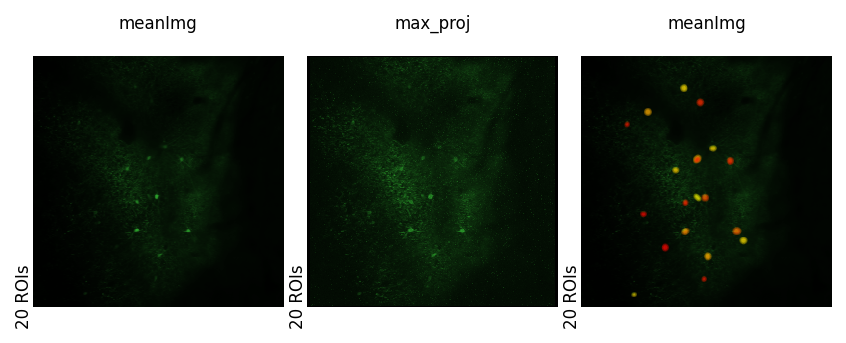

In [150]:
fig, AX = pt.figure(axes=(3,1), figsize=(1.4,3), wspace=0.15)

from physion.dataviz.imaging import show_CaImaging_FOV
#
show_CaImaging_FOV(data, key='meanImg', 
                   cmap=pt.get_linear_colormap('k', 'tab:green'),
                   NL=2, # non-linearity to normalize image
                   ax=AX[0])
show_CaImaging_FOV(data, key='max_proj', 
                   cmap=pt.get_linear_colormap('k', 'tab:green'),
                   NL=2, # non-linearity to normalize image
                   ax=AX[1])
show_CaImaging_FOV(data, key='meanImg', 
                   cmap=pt.get_linear_colormap('k', 'tab:green'),
                   NL=2,
                   roiIndices=range(data.nROIs), 
                   ax=AX[2])


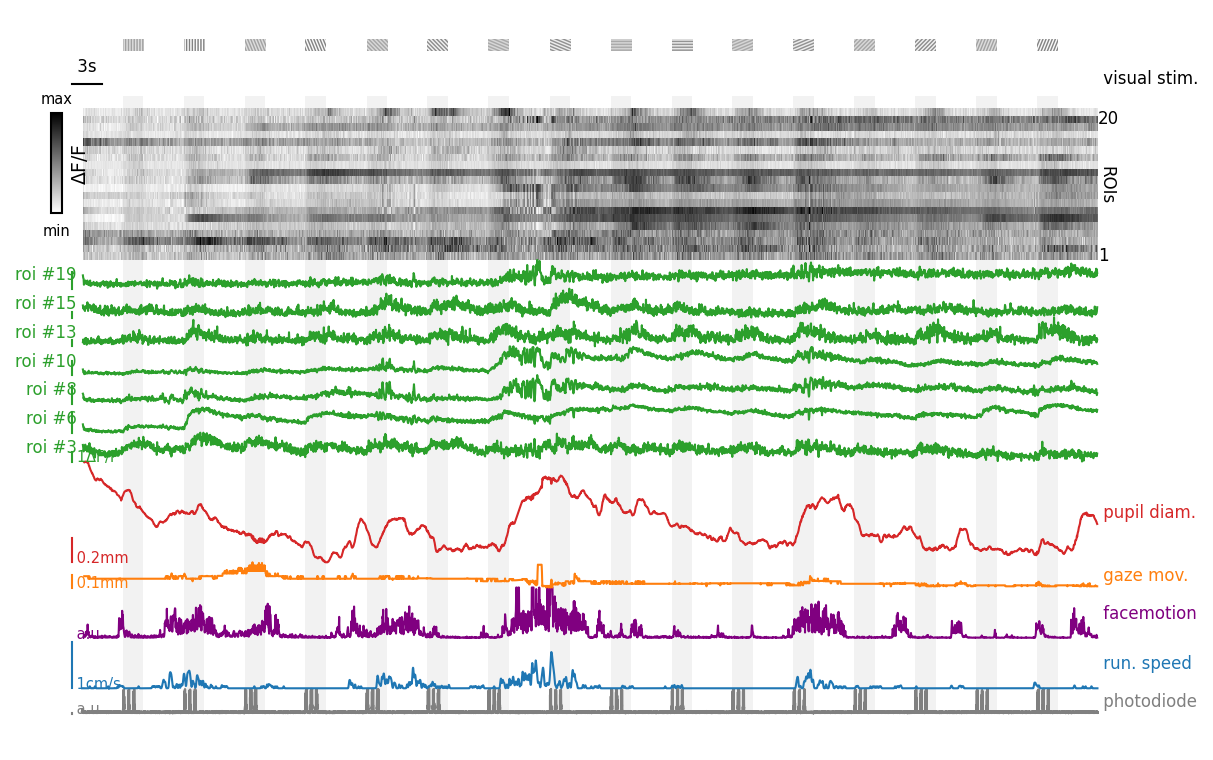

In [151]:
from physion.dataviz.raw import plot as plot_raw, find_default_plot_settings
settings_ = find_default_plot_settings(data)
_ = plot_raw(data, settings=settings_)  #??? (zoom)

problems with photodiode!!

## Show overall traces

(<Figure size 1350x900 with 1 Axes>, <Axes: >)

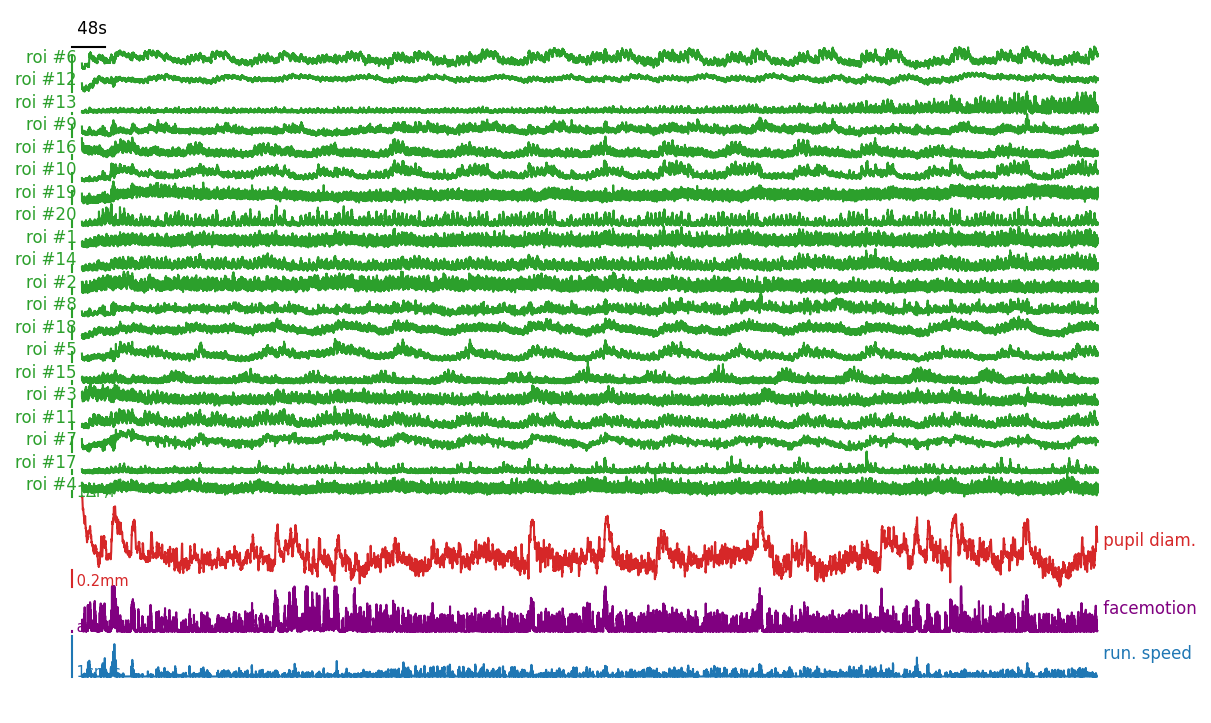

In [152]:
plot_raw(data, tlim=[0, data.t_dFoF[-1]], settings=settings)

## See if parameters are similar within each episode block (8 episodes)

In [36]:
from physion.analysis.process_NWB import EpisodeData

In [2]:
ep = EpisodeData(data,
                 prestim_duration=2,
                 protocol_id=0,
                 quantities=['dFoF', 'pupil_diameter', 'facemotion', 'running_speed'])


print(ep.dFoF.shape) # (episodes, rois, time samples)
n_episodes = ep.dFoF.shape[0]
roi = random.randint(0, 19)  #3

bin_size = 8
bins = int(n_episodes/bin_size)
print(bins)
norm_cond = (ep.t>-0.1) & (ep.t<0)
fig, ax = plt.subplots(nrows=4, ncols= 1, figsize =(8, 6))
print(roi)

for i in range(bins):
    #print("bin : [", i*bin_size," ; ", (1+i)*bin_size, "]")
    #temp = ep.dFoF[i*bin_size:(1+i)*bin_size,:,:].mean(axis=1).mean(axis=0)
    #ax.plot(ep.t, temp-temp[norm_cond].mean(), color=pt.get_linear_colormap('y', 'b')(i/bins))
    dFoF = ep.dFoF[i*bin_size:(1+i)*bin_size,roi,:].mean(axis=0)
    ax[0].plot(ep.t, dFoF, color=pt.get_linear_colormap('y', 'b')(i/bins))
    ax[0].axvspan(0, 2, color='lightgrey')
    ax[0].set_title('CaImaging')
     
    runn_speed = ep.running_speed[i*bin_size:(1+i)*bin_size].mean(axis=0)
    ax[1].plot(ep.t, runn_speed, color=pt.get_linear_colormap('y', 'b')(i/bins), label = 'running speed')
    ax[1].axvspan(0, 2, color='lightgrey')
    ax[1].set_title('Running Speed')
    
    pupil_size = ep.pupil_diameter[i*bin_size:(1+i)*bin_size].mean(axis=0)
    ax[2].plot(ep.t, pupil_size, color=pt.get_linear_colormap('y', 'b')(i/bins), label = 'pupil_size')
    ax[2].axvspan(0, 2, color='lightgrey')
    ax[2].set_title('pupil size')
    
    face_whisk = ep.faceMotion[i*bin_size:(1+i)*bin_size].mean(axis=0)
    ax[3].plot(ep.t, face_whisk, color=pt.get_linear_colormap('y', 'b')(i/bins), label = 'face_whisk')
    ax[3].axvspan(0, 2, color='lightgrey')
    ax[3].set_title('face_whisk')

#plt.legend()
plt.tight_layout()

NameError: name 'EpisodeData' is not defined